---
# Финальный пайплайн: прогноз согласия клиента на кредитный офер
---

**Задача:** оценить вероятность $\hat{p}_i = P(y_i = 1 \mid X_i)$, где $y_i \in \{0,1\}$ -- факт принятия офера.
**Метрика:** ROC-AUC. **Валидация:** train < 2025-02-01, valid >= 2025-02-01.

| | |
|---|---|
| Feature set | reduced_v2_no_ratios (82 признака) |
| Ансамбль | Greedy blend: XGBoost + CatBoost + LightGBM |
| ROC-AUC (valid) | **0.768359** |
| PR-AUC (valid) | **0.329786** |


----
**Разведочный анализ данных (EDA)**
----
----

Цель EDA - установить, какие признаки несут реальный сигнал для предсказания согласия клиента, выявить источники утечки данных и дрейфа распределений между train и test, и сформировать гипотезы для feature engineering.


In [1]:
%pip install -q pandas numpy matplotlib seaborn scipy scikit-learn lightgbm xgboost catboost


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 11,
})

TARGET_COL = "target_value"
ID_COL = "front_id"
DATE_COL = "decision_day"

train_df = pd.read_csv(r"data\train_apps.csv")
test_df = pd.read_csv(r"data\test_apps.csv")

train_df[DATE_COL] = pd.to_datetime(train_df[DATE_COL])
test_df[DATE_COL] = pd.to_datetime(test_df[DATE_COL])

print(f"Train: {train_df.shape} | Test: {test_df.shape}")
print(f"Train dates: {train_df[DATE_COL].min().date()} - {train_df[DATE_COL].max().date()}")
print(f"Test dates:  {test_df[DATE_COL].min().date()} - {test_df[DATE_COL].max().date()}")
print(f"Target rate (train): {train_df[TARGET_COL].mean():.4f}")


Train: (145241, 28) | Test: (36311, 27)
Train dates: 2024-02-01 — 2025-06-05
Test dates:  2025-06-05 — 2025-12-01
Target rate (train): 0.0609


### **Обзор данных и целевой переменной**

Задача характеризуется **сильным дисбалансом классов**: доля согласий (`target_value = 1`) составляет около 7–9%, что типично для кредитного маркетинга. Это означает, что точность (accuracy) - бесполезная метрика: модель, всегда предсказывающая «0», даёт > 90% accuracy при нулевой практической ценности.

Ключевые наблюдения:
- **Временная нестабильность target rate**: доля согласий заметно варьируется по месяцам - причина в сезонности и изменении условий офера. Это обосновывает выбор *временного*, а не случайного split для валидации.
- **Признак `decision_day`**: дата принятия решения находится в промежутке `2024-02-01 - 2025-06-05` (train) и `2025-06-05 - 2025-12-01` (test), что создаёт гарантированный временной сдвиг между выборками.


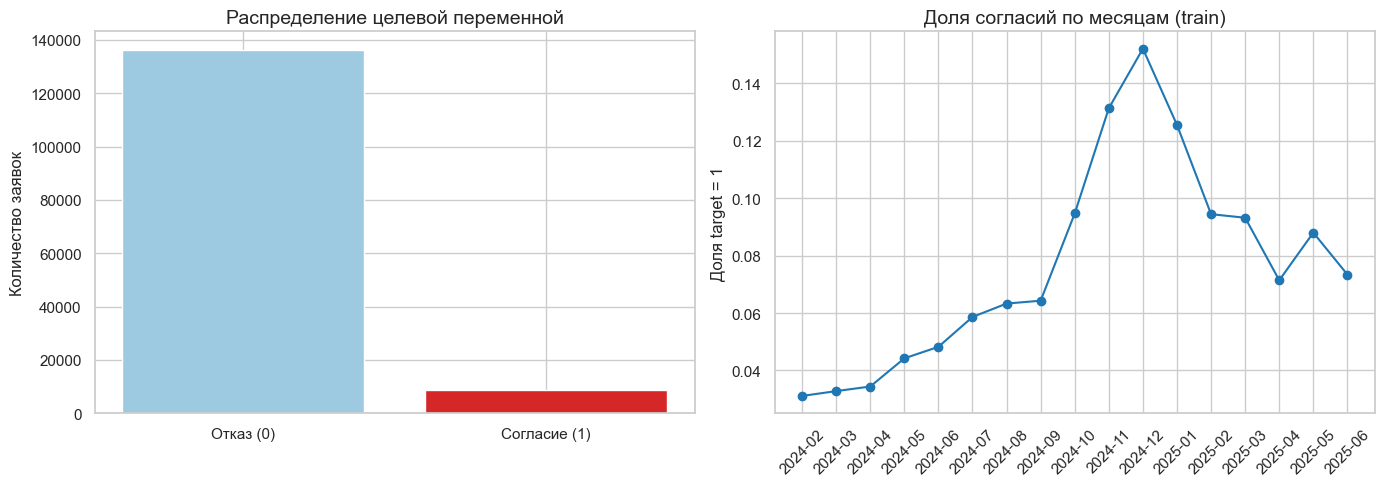

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_counts = train_df[TARGET_COL].value_counts().sort_index()
axes[0].bar(
    ["Отказ (0)", "Согласие (1)"],
    target_counts.values,
    color=["#9ecae1", "#d62728"],
)
axes[0].set_title("Распределение целевой переменной")
axes[0].set_ylabel("Количество заявок")

monthly = (
    train_df.assign(month=train_df[DATE_COL].dt.to_period("M").astype(str))
    .groupby("month")[TARGET_COL]
    .mean()
)
axes[1].plot(monthly.index, monthly.values, marker="o", color="#1f77b4")
axes[1].set_title("Доля согласий по месяцам (train)")
axes[1].set_ylabel("Доля target = 1")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


### **Пропуски как сигнал**

20 из 25 сырых признаков содержат пропуски (от 17% до 96%). Механизм пропусков - **MNAR** (Missing Not At Random): отсутствие записей в кредитной истории само по себе характеризует клиента (нет истории овердрафтов → клиент, скорее всего, не пользовался продуктом).

Для каждого столбца $j$ с пропусками вводится **бинарный индикатор**:

$$m_{ij} = \mathbf{1}\!\left[x_{ij} \text{ is NaN}\right] \in \{0, 1\}$$

Совокупная полнота профиля описывается двумя агрегатами:

$$
\text{missing\_count}_i = \sum_j m_{ij}, \qquad
\text{missing\_share}_i = \frac{\text{missing\_count}_i}{d},
$$

где $d$ - число признаков. Чем полнее профиль клиента (меньше `missing_count`), тем выше acceptance rate. Это один из сильнейших блоков сигнала в данных.

> **Вывод:** пропуски не заполняются - они кодируются явно. Импутация числовых значений при MNAR-механизме стирает информативный сигнал «есть данные / нет данных».


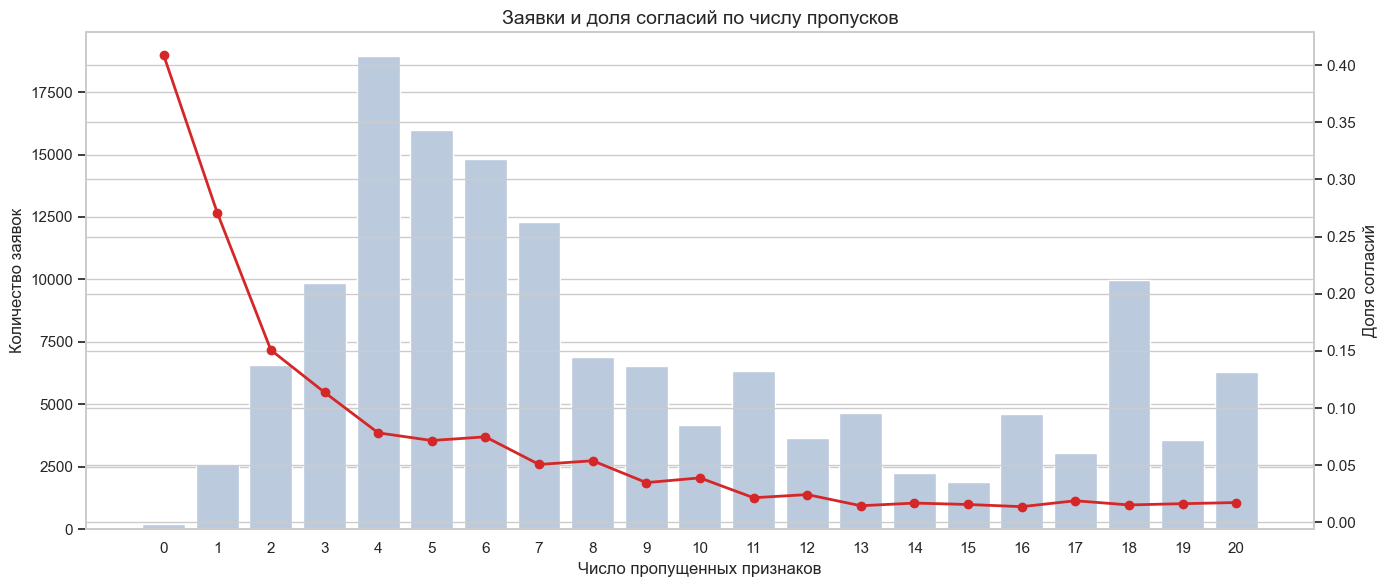

In [4]:
def safe_divide(a, b):
    return a / (np.abs(b) + 1e-6)


def add_eda_features(data):
    result = data.copy()
    feature_cols = [c for c in result.columns if c not in [TARGET_COL, ID_COL, DATE_COL]]
    result["missing_count"] = result[feature_cols].isna().sum(axis=1)
    result["rate_spread"] = result["offered_rate"] - result["cb_rate"]
    return result


train_eda = add_eda_features(train_df)

missing_count_stats = (
    train_eda.groupby("missing_count")
    .agg(applications=(ID_COL, "count"), target_rate=(TARGET_COL, "mean"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=missing_count_stats, x="missing_count", y="applications", color="#B7C9E2", ax=ax)
ax.set_title("Заявки и доля согласий по числу пропусков")
ax.set_xlabel("Число пропущенных признаков")
ax.set_ylabel("Количество заявок")

ax2 = ax.twinx()
ax2.plot(
    missing_count_stats["missing_count"],
    missing_count_stats["target_rate"],
    color="#D62728",
    marker="o",
    linewidth=2,
)
ax2.set_ylabel("Доля согласий")
plt.tight_layout()
plt.show()


### **Временной дрейф train → test**

Между train и test существует **6-месячный разрыв** без перекрытия. Ряд признаков меняет своё распределение из-за изменения макроэкономических условий и банковской политики. Для количественной оценки дрейфа используется **Population Stability Index (PSI)**:

$$
\text{PSI} = \sum_{k=1}^{K} \left( p^{\text{test}}_k - p^{\text{train}}_k \right) \cdot \ln\!\frac{p^{\text{test}}_k}{p^{\text{train}}_k},
$$

где $p^{\text{train}}_k$, $p^{\text{test}}_k$ - доли наблюдений в $k$-м бине для train и test соответственно.

Интерпретация PSI: $< 0.1$ - стабильно, $0.1$–$0.25$ - умеренный дрейф, $> 0.25$ - нестабильно.

**Наибольший дрейф** у `offered_rate`, `cb_rate`, `rate_ratio` и `rate_spread` - признаки, отражающие абсолютный уровень процентных ставок. По этой причине **ratio-признаки исключены из финального набора** `reduced_v2_no_ratios`: они улучшают CV на train-периоде, но деградируют на test из-за нестабильности знаменателя (`cb_rate` близко к нулю в части test-записей).


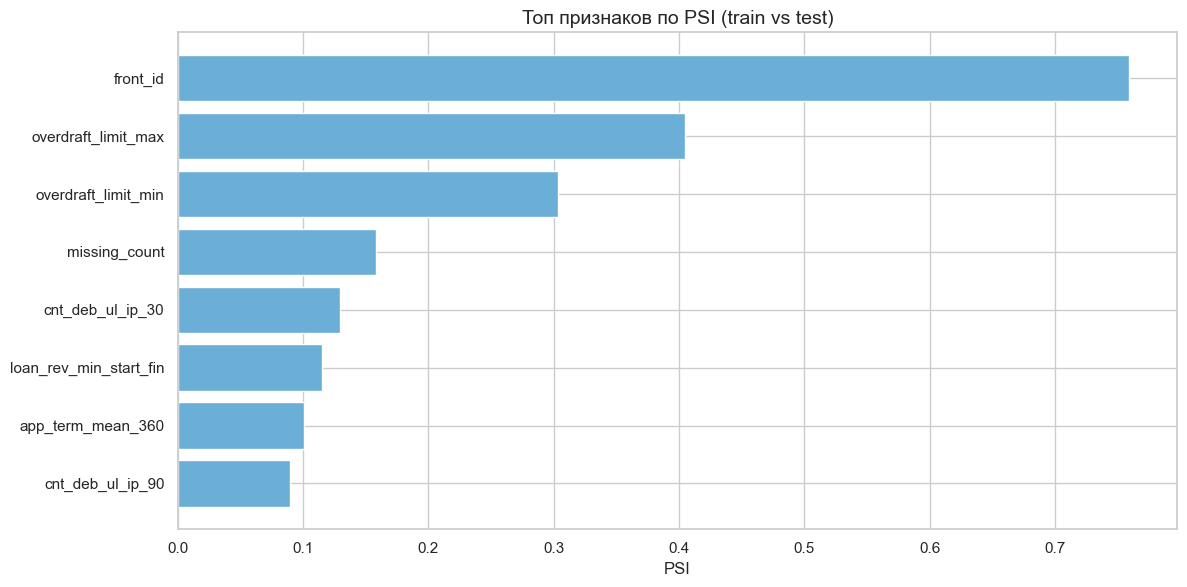

In [5]:
def psi_score(train_values, test_values, bins=10):
    train_values = pd.Series(train_values).dropna()
    test_values = pd.Series(test_values).dropna()
    if len(train_values) == 0 or len(test_values) == 0:
        return np.nan
    cuts = np.unique(np.quantile(train_values, np.linspace(0, 1, bins + 1)))
    if len(cuts) < 3:
        return np.nan
    train_hist = pd.cut(train_values, bins=cuts, include_lowest=True).value_counts(normalize=True)
    test_hist = pd.cut(test_values, bins=cuts, include_lowest=True).value_counts(normalize=True)
    aligned = pd.concat([train_hist, test_hist], axis=1, keys=["train", "test"]).fillna(1e-6)
    return ((aligned["test"] - aligned["train"]) * np.log(aligned["test"] / aligned["train"])).sum()


train_tmp = add_eda_features(train_df)
test_tmp = add_eda_features(test_df)
train_tmp["decision_day_num"] = (train_tmp[DATE_COL] - train_tmp[DATE_COL].min()).dt.days
test_tmp["decision_day_num"] = (test_tmp[DATE_COL] - train_tmp[DATE_COL].min()).dt.days

drift_rows = []
for col in train_tmp.select_dtypes(include="number").columns:
    if col in test_tmp.columns:
        drift_rows.append({
            "feature": col,
            "psi": psi_score(train_tmp[col], test_tmp[col]),
            "ks_stat": ks_2samp(train_tmp[col].dropna(), test_tmp[col].dropna()).statistic,
        })

drift_df = pd.DataFrame(drift_rows).sort_values("psi", ascending=False).head(12)

plt.figure(figsize=(12, 6))
plt.barh(drift_df["feature"], drift_df["psi"], color="#6baed6")
plt.gca().invert_yaxis()
plt.title("Топ признаков по PSI (train vs test)")
plt.xlabel("PSI")
plt.tight_layout()
plt.show()


### **Продуктовый сегмент `db_group_last`**

Признак `db_group_last` - тип последнего кредитного продукта клиента в банке - является одним из **сильнейших предикторов**. Ключевой эффект:

- Сегмент **`overdraft`**: acceptance rate ≈ 37% - почти в 5× выше глобального среднего (~7–9%). Клиенты с активным овердрафтом уже вовлечены в кредитные отношения с банком и склонны принимать новые предложения.
- Отсутствие записи (`NaN`, ≈38% train): клиент либо новый, либо не имеет истории в системе - acceptance rate существенно ниже.

Признак имеет **38% пропусков** и **дрейфует** между выборками (PSI > 0.1). Для корректной передачи этой информации в модель применяется:
1. Категориальная кодировка с отдельной категорией `__MISSING__` для пропусков.
2. Частотное кодирование (`db_group_last_freq`) - доля каждого сегмента в обучающей выборке.


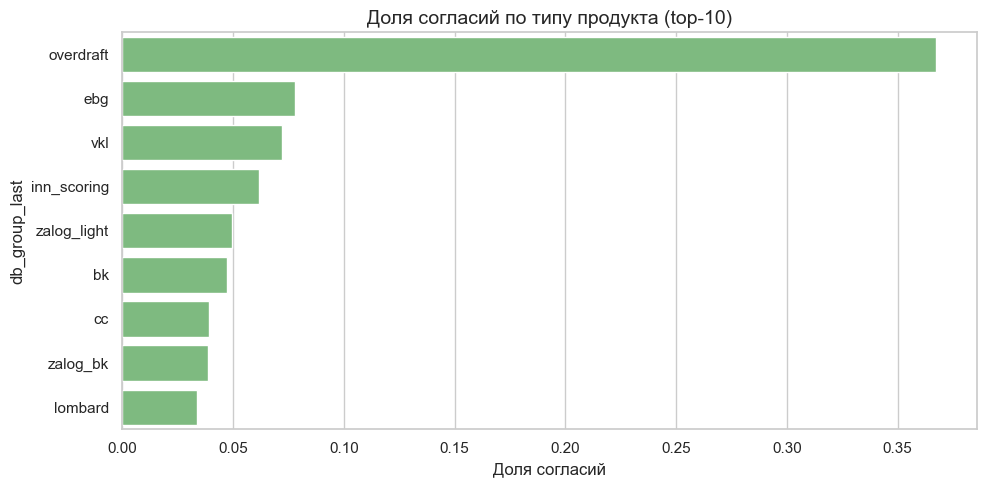

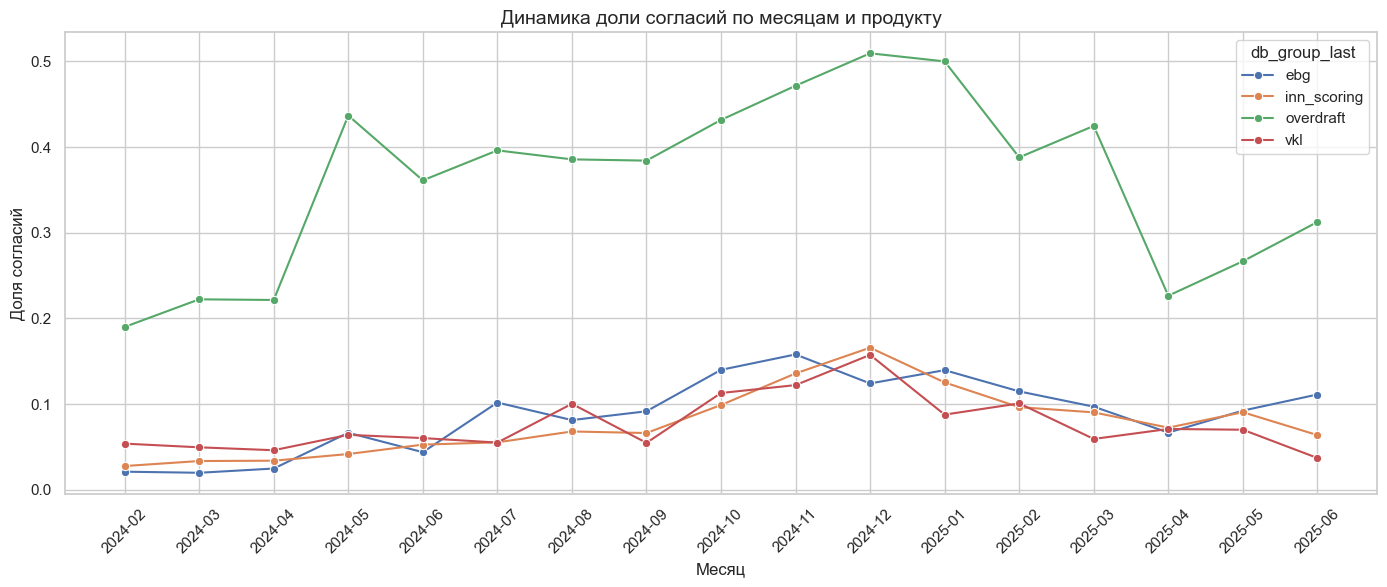

In [6]:
product_stats = (
    train_df.groupby("db_group_last")[TARGET_COL]
    .agg(count="count", target_rate="mean")
    .sort_values("target_rate", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=product_stats.reset_index(),
    y="db_group_last",
    x="target_rate",
    color="#74c476",
)
plt.title("Доля согласий по типу продукта (top-10)")
plt.xlabel("Доля согласий")
plt.ylabel("db_group_last")
plt.tight_layout()
plt.show()

monthly_product = (
    train_df.assign(month=train_df[DATE_COL].dt.to_period("M").astype(str))
    .groupby(["month", "db_group_last"])[TARGET_COL]
    .mean()
    .reset_index()
)

top_products = product_stats.head(4).index.tolist()
plot_monthly = monthly_product[monthly_product["db_group_last"].isin(top_products)]

plt.figure(figsize=(14, 6))
sns.lineplot(data=plot_monthly, x="month", y=TARGET_COL, hue="db_group_last", marker="o")
plt.title("Динамика доли согласий по месяцам и продукту")
plt.ylabel("Доля согласий")
plt.xlabel("Месяц")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


----
**Кластеризация поведенческих профилей**
----
----

KMeans применяется на поведенческих признаках (кредитная активность, цифровая активность) с визуализацией через PCA для понимания структуры данных.

**Результат:** кластеры хорошо описывают **архетип клиента** (активный заёмщик vs новый клиент), но target `y` **размазан внутри каждого кластера** - acceptance rate существенно не различается между кластерами, когда контролируются другие признаки. Это означает, что решение о согласии определяется не профилем клиента целиком, а конкретными параметрами офера и моментом его получения.

> **Вывод:** кластерные признаки (`cluster_id`, `cluster_target_rate`) **не вошли в финальную модель** - на validation они не давали прироста ROC-AUC и добавляли риск переобучения из-за утечки целевого сигнала при сглаживании.


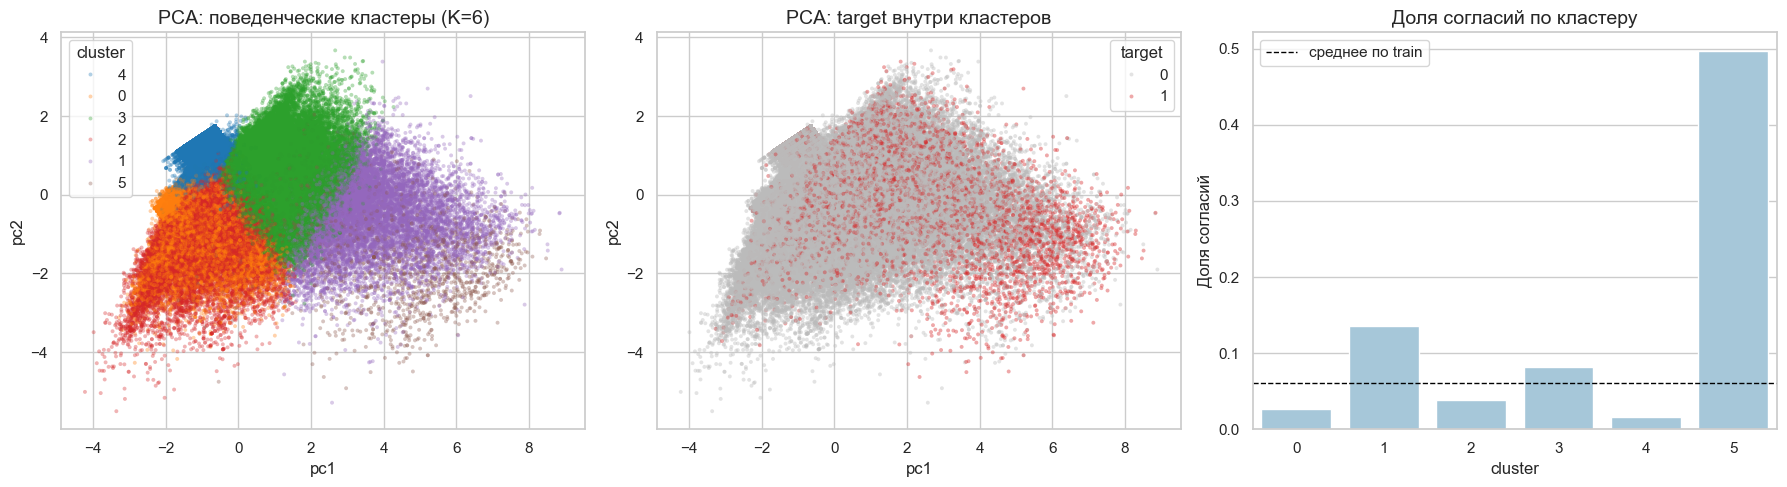

In [7]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

CLUSTER_K = 6
CUTOFF = pd.Timestamp("2025-02-01")

behavior_cols = [
    "loan_rev_max_start_non_fin",
    "overdraft_limit_max",
    "sum_deb_ul_90",
    "cnt_deb_loan_90",
    "cnt_cred_loan_90",
    "cnt_deb_ul_ip_90",
    "missing_count",
    "corp_credit_products",
    "count_all_corp_dashboard_events",
]

eda_cluster = add_eda_features(train_df)
eda_cluster = eda_cluster[eda_cluster[DATE_COL] < CUTOFF].copy()

X_beh = eda_cluster[behavior_cols].replace([np.inf, -np.inf], np.nan)
medians = X_beh.median()
X_beh = X_beh.fillna(medians)
X_scaled = StandardScaler().fit_transform(X_beh)

pca2 = PCA(n_components=2, random_state=42)
xy = pca2.fit_transform(X_scaled)
labels = KMeans(n_clusters=CLUSTER_K, random_state=42, n_init=20).fit_predict(X_scaled)

plot_df = pd.DataFrame({
    "pc1": xy[:, 0],
    "pc2": xy[:, 1],
    "cluster": labels.astype(str),
    "target": eda_cluster[TARGET_COL].values,
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=plot_df, x="pc1", y="pc2", hue="cluster", palette="tab10",
    s=8, alpha=0.35, linewidth=0, ax=axes[0],
)
axes[0].set_title(f"PCA: поведенческие кластеры (K={CLUSTER_K})")

sns.scatterplot(
    data=plot_df, x="pc1", y="pc2", hue="target",
    palette={0: "#bbbbbb", 1: "#d62728"},
    s=8, alpha=0.4, linewidth=0, ax=axes[1],
)
axes[1].set_title("PCA: target внутри кластеров")
axes[1].legend(title="target", loc="best")

cluster_rates = plot_df.groupby("cluster")["target"].mean().reset_index()
sns.barplot(data=cluster_rates, x="cluster", y="target", color="#9ecae1", ax=axes[2])
axes[2].axhline(
    train_df[TARGET_COL].mean(), color="black", linestyle="--", linewidth=1, label="среднее по train",
)
axes[2].set_title("Доля согласий по кластеру")
axes[2].set_ylabel("Доля согласий")
axes[2].legend()

plt.tight_layout()
plt.show()


----
**Моделирование: feature engineering и greedy blend**
----
----

### **Стратегия валидации**

Поскольку test строго **позже** train по времени, случайный split давал бы оптимистичные оценки - модель обучалась бы на данных «из будущего» относительно части validation. Применяется **hard temporal cutoff**:

$$
\mathcal{D}_\text{train} = \{i : d_i < \texttt{2025-02-01}\}, \quad
\mathcal{D}_\text{valid} = \{i : d_i \geq \texttt{2025-02-01}\},
$$

где $d_i$ - дата решения по заявке $i$.

### **Feature engineering: `reduced_v2_no_ratios`**

Итоговый набор строится в несколько этапов:

1. **Сырые признаки** (25) - offer, лимиты, кредитная история, корпоративная активность.
2. **Индикаторы пропусков** `{col}_isna` + `missing_count` + `missing_share` - явное кодирование MNAR-сигнала.
3. **Частотное кодирование** категорий `db_group_last`, `fl_adminarea` - частоты считаются по объединённому train+test, без утечки целевой переменной.
4. **Удаление коллинеарных** признаков (`overdraft_limit_min`, `cnt_deb_ul_ip_30`, `sum_deb_ul_30`).
5. **Удаление нестабильных ratio** (`rate_ratio`, `loan_to_limit_*`, `rate_spread` и производных) - дрейф train→test деградирует public score.
6. **Удаление слабых calendar-признаков** (`decision_dayofmonth`, `decision_weekofyear`, `decision_quarter`, `is_month_start`, `is_month_end`) - не несут устойчивого сигнала.

Итого: **82 признака**.

### **Модели**

| Модель | Ключевые параметры |
|---|---|
| `XGBoost` | `max_depth=4`, `lr=0.035`, `n_est=1000`, early stopping |
| `CatBoost` | `depth=6`, `lr=0.035`, `iter=1200`, native cat support |
| `LightGBM` | `num_leaves=31`, `lr=0.03`, `n_est=1400`, early stopping |

Все модели используют **early stopping по ROC-AUC на valid** - это предотвращает переобучение без ручного подбора числа итераций.


In [8]:
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42
CAT_COLS = ["db_group_last", "fl_adminarea"]

HIGH_CORR_DROP_COLS = [
    "overdraft_limit_min",
    "cnt_deb_ul_ip_30",
    "sum_deb_ul_30",
    "decision_day_num",
]

REDUCED_V2_DROP = [
    "rate_ratio",
    "decision_day_num",
    "decision_weekofyear",
    "decision_dayofmonth",
    "decision_quarter",
    "is_month_start",
    "is_month_end",
    "is_sunday",
    "loan_to_limit_min",
    "loan_to_limit_mean",
    "sum_deb_ul_ratio_30_90",
    "cnt_deb_ul_ip_ratio_30_90",
    "sum_deb_ul_per_cnt_30",
    "digital_activity_per_time",
    "credit_activity_ratio",
]

RATIO_ENGINEERED_COLS = [
    "rate_spread",
    "abs_rate_spread",
    "rate_ratio",
    "overdraft_range",
    "overdraft_mean",
    "loan_to_limit_min",
    "loan_to_limit_max",
    "loan_to_limit_mean",
    "loan_minus_limit_max",
    "loan_minus_limit_min",
    "sum_deb_ul_ratio_30_90",
    "cnt_deb_ul_ip_ratio_30_90",
    "sum_deb_ul_diff_90_30",
    "cnt_deb_ul_ip_diff_90_30",
    "sum_deb_ul_per_cnt_90",
    "sum_deb_ul_per_cnt_30",
    "credit_activity_balance",
    "credit_activity_ratio",
    "digital_activity_sum",
    "digital_activity_per_time",
]


def add_calendar_features(data, min_date=None):
    result = data.copy()
    result[DATE_COL] = pd.to_datetime(result[DATE_COL])
    if min_date is None:
        min_date = result[DATE_COL].min()
    result["decision_day_num"] = (result[DATE_COL] - min_date).dt.days
    result["decision_month"] = result[DATE_COL].dt.month
    result["decision_quarter"] = result[DATE_COL].dt.quarter
    result["decision_weekofyear"] = result[DATE_COL].dt.isocalendar().week.astype(int)
    result["decision_dayofweek"] = result[DATE_COL].dt.weekday
    result["decision_dayofmonth"] = result[DATE_COL].dt.day
    result["is_weekend"] = result["decision_dayofweek"].isin([5, 6]).astype(int)
    result["is_sunday"] = (result["decision_dayofweek"] == 6).astype(int)
    result["is_month_start"] = result[DATE_COL].dt.is_month_start.astype(int)
    result["is_month_end"] = result[DATE_COL].dt.is_month_end.astype(int)
    return result


def add_ratio_features(data):
    result = data.copy()
    result["rate_spread"] = result["offered_rate"] - result["cb_rate"]
    result["abs_rate_spread"] = result["rate_spread"].abs()
    result["rate_ratio"] = safe_divide(result["offered_rate"], result["cb_rate"])
    result["overdraft_range"] = result["overdraft_limit_max"] - result["overdraft_limit_min"]
    result["overdraft_mean"] = (result["overdraft_limit_max"] + result["overdraft_limit_min"]) / 2
    result["loan_to_limit_min"] = safe_divide(result["loan_amount_last"], result["overdraft_limit_min"])
    result["loan_to_limit_max"] = safe_divide(result["loan_amount_last"], result["overdraft_limit_max"])
    result["loan_to_limit_mean"] = safe_divide(result["loan_amount_last"], result["overdraft_mean"])
    result["loan_minus_limit_max"] = result["loan_amount_last"] - result["overdraft_limit_max"]
    result["loan_minus_limit_min"] = result["loan_amount_last"] - result["overdraft_limit_min"]
    result["sum_deb_ul_ratio_30_90"] = safe_divide(result["sum_deb_ul_30"], result["sum_deb_ul_90"])
    result["cnt_deb_ul_ip_ratio_30_90"] = safe_divide(result["cnt_deb_ul_ip_30"], result["cnt_deb_ul_ip_90"])
    result["sum_deb_ul_diff_90_30"] = result["sum_deb_ul_90"] - result["sum_deb_ul_30"]
    result["cnt_deb_ul_ip_diff_90_30"] = result["cnt_deb_ul_ip_90"] - result["cnt_deb_ul_ip_30"]
    result["sum_deb_ul_per_cnt_90"] = safe_divide(result["sum_deb_ul_90"], result["cnt_deb_ul_ip_90"])
    result["sum_deb_ul_per_cnt_30"] = safe_divide(result["sum_deb_ul_30"], result["cnt_deb_ul_ip_30"])
    result["credit_activity_balance"] = result["cnt_cred_loan_90"] - result["cnt_deb_loan_90"]
    result["credit_activity_ratio"] = safe_divide(result["cnt_cred_loan_90"], result["cnt_deb_loan_90"])
    result["digital_activity_sum"] = (
        result["corp_credit_products"]
        + result["corp_list"]
        + result["count_all_corp_dashboard_events"]
        + result["p75_time_spent_minutes"]
    )
    result["digital_activity_per_time"] = safe_divide(
        result["count_all_corp_dashboard_events"], result["p75_time_spent_minutes"]
    )
    return result


def add_missing_features(data):
    result = data.copy()
    feature_cols = [c for c in result.columns if c not in [TARGET_COL, ID_COL, DATE_COL]]
    numeric_cols = result[feature_cols].select_dtypes(include="number").columns.tolist()
    for col in numeric_cols:
        result[f"{col}_isna"] = result[col].isna().astype(int)
    result["missing_count"] = result[feature_cols].isna().sum(axis=1)
    result["missing_share"] = result["missing_count"] / len(feature_cols)
    return result


def add_frequency_features(train_data, test_data=None):
    train_result = train_data.copy()
    test_result = None if test_data is None else test_data.copy()
    frequency_source = train_result if test_data is None else pd.concat(
        [train_result, test_result], axis=0, ignore_index=True
    )
    for col in CAT_COLS:
        freq = frequency_source[col].fillna("__MISSING__").value_counts(normalize=True)
        train_result[f"{col}_freq"] = train_result[col].fillna("__MISSING__").map(freq).astype(float)
        if test_result is not None:
            test_result[f"{col}_freq"] = test_result[col].fillna("__MISSING__").map(freq).astype(float)
    return train_result, test_result


def build_feature_set(train_data, test_data=None, feature_set="ratio_reduced"):
    min_date = pd.to_datetime(train_data[DATE_COL]).min()
    train_result = add_calendar_features(train_data, min_date=min_date)
    test_result = None if test_data is None else add_calendar_features(test_data, min_date=min_date)
    if feature_set in ["ratio", "ratio_reduced"]:
        train_result = add_ratio_features(train_result)
        if test_result is not None:
            test_result = add_ratio_features(test_result)
    train_result = add_missing_features(train_result)
    if test_result is not None:
        test_result = add_missing_features(test_result)
    train_result, test_result = add_frequency_features(train_result, test_result)
    if feature_set in ["reduced", "ratio_reduced"]:
        drop_cols = [c for c in HIGH_CORR_DROP_COLS if c in train_result.columns]
        train_result = train_result.drop(columns=drop_cols)
        if test_result is not None:
            test_result = test_result.drop(columns=drop_cols)
    drop_cols = [ID_COL, DATE_COL]
    X_train = train_result.drop(columns=[c for c in drop_cols + [TARGET_COL] if c in train_result.columns])
    y_train = train_result[TARGET_COL] if TARGET_COL in train_result.columns else None
    X_test = None
    if test_result is not None:
        X_test = test_result.drop(columns=[c for c in drop_cols + [TARGET_COL] if c in test_result.columns])
    for col in CAT_COLS:
        if col in X_train.columns:
            X_train[col] = X_train[col].fillna("__MISSING__").astype(str)
        if X_test is not None and col in X_test.columns:
            X_test[col] = X_test[col].fillna("__MISSING__").astype(str)
    return X_train, y_train, X_test


def apply_reduced_v2_no_ratios(X):
    drop_cols = list(set(REDUCED_V2_DROP + RATIO_ENGINEERED_COLS))
    drop_cols = [c for c in drop_cols if c in X.columns]
    return X.drop(columns=drop_cols)


In [9]:
def prepare_model_data(X_train, X_valid, model_name):
    X_train_ready = X_train.copy()
    X_valid_ready = X_valid.copy()
    numeric_cols = X_train_ready.select_dtypes(include="number").columns.tolist()
    X_train_ready[numeric_cols] = X_train_ready[numeric_cols].replace([np.inf, -np.inf], np.nan)
    X_valid_ready[numeric_cols] = X_valid_ready[numeric_cols].replace([np.inf, -np.inf], np.nan)
    existing_cat_cols = [c for c in CAT_COLS if c in X_train_ready.columns]

    if model_name.startswith("cat"):
        for col in existing_cat_cols:
            X_train_ready[col] = X_train_ready[col].fillna("__MISSING__").astype(str)
            X_valid_ready[col] = X_valid_ready[col].fillna("__MISSING__").astype(str)
        return X_train_ready, X_valid_ready, [X_train_ready.columns.get_loc(c) for c in existing_cat_cols]

    if model_name.startswith("lgbm"):
        for col in existing_cat_cols:
            X_train_ready[col] = X_train_ready[col].fillna("__MISSING__").astype("category")
            X_valid_ready[col] = X_valid_ready[col].fillna("__MISSING__").astype("category")
        return X_train_ready, X_valid_ready, existing_cat_cols

    if model_name.startswith("xgb"):
        for col in existing_cat_cols:
            combined = pd.concat([X_train_ready[col], X_valid_ready[col]], axis=0).fillna("__MISSING__").astype(str)
            categories = {v: i for i, v in enumerate(combined.unique())}
            X_train_ready[col] = X_train_ready[col].fillna("__MISSING__").astype(str).map(categories).astype(int)
            X_valid_ready[col] = X_valid_ready[col].fillna("__MISSING__").astype(str).map(categories).fillna(-1).astype(int)
        return X_train_ready, X_valid_ready, None

    raise ValueError(model_name)


def make_model(model_name):
    if model_name == "lgbm_base":
        return LGBMClassifier(
            objective="binary",
            n_estimators=1400,
            learning_rate=0.03,
            num_leaves=31,
            min_child_samples=60,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.2,
            reg_lambda=6.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    if model_name == "xgb_base":
        return XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            n_estimators=1000,
            learning_rate=0.035,
            max_depth=4,
            min_child_weight=8,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.1,
            reg_lambda=6.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
        )
    if model_name == "cat_base":
        return CatBoostClassifier(
            iterations=1200,
            learning_rate=0.035,
            depth=6,
            l2_leaf_reg=8,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=RANDOM_STATE,
            allow_writing_files=False,
            verbose=False,
            od_type="Iter",
            od_wait=100,
        )
    raise ValueError(model_name)


def fit_predict_model(model_name, X_train, y_train, X_valid, y_valid):
    X_train_ready, X_valid_ready, cat_features = prepare_model_data(X_train, X_valid, model_name)
    model = make_model(model_name)
    if model_name.startswith("cat"):
        model.fit(
            X_train_ready,
            y_train,
            cat_features=cat_features,
            eval_set=(X_valid_ready, y_valid),
            use_best_model=True,
        )
    elif model_name.startswith("lgbm"):
        model.fit(
            X_train_ready,
            y_train,
            eval_set=[(X_valid_ready, y_valid)],
            categorical_feature=cat_features,
        )
    else:
        model.fit(X_train_ready, y_train, eval_set=[(X_valid_ready, y_valid)], verbose=False)
    return model, model.predict_proba(X_valid_ready)[:, 1]


def evaluate_predictions(y_true, y_pred):
    return {
        "roc_auc": roc_auc_score(y_true, y_pred),
        "pr_auc": average_precision_score(y_true, y_pred),
        "logloss": log_loss(y_true, np.clip(y_pred, 1e-6, 1 - 1e-6)),
    }


### **Greedy blend**

Жадный ансамбль строится итеративно: на каждом шаге выбирается кандидат и вес $w^*$, максимизирующие ROC-AUC на validation:

$$
\hat{p}^{(t)} = w^* \cdot \hat{p}^{(t-1)} + (1 - w^*) \cdot \hat{p}_{\text{candidate}},
$$

$$
w^* = \arg\max_{w \in \{0.1,\, 0.2,\, \ldots,\, 0.9\}} \;\text{ROC-AUC}\!\left(y_\text{valid},\; w \cdot \hat{p}^{(t-1)} + (1-w) \cdot \hat{p}_\text{candidate}\right).
$$

Алгоритм останавливается, если ни один кандидат не улучшает метрику. Преимущество перед простым усреднением: разные модели вносят **некоррелированные ошибки** - XGBoost обрабатывает числовые признаки иначе, чем CatBoost с нативной поддержкой категорий, LGBM добавляет leaf-wise рост деревьев. Их комбинация снижает дисперсию итогового предсказания.


Train: 127073 | Valid: 18168 | Features: 82
Обучение xgb_base__reduced_v2_no_ratios...
  ROC-AUC=0.768102 | PR-AUC=0.327987
Обучение cat_base__reduced_v2_no_ratios...
  ROC-AUC=0.759763 | PR-AUC=0.320531
Обучение lgbm_base__reduced_v2_no_ratios...
  ROC-AUC=0.757397 | PR-AUC=0.312811

Greedy blend:
  ROC-AUC=0.768359 | PR-AUC=0.329786
  Модели: ['xgb_base__reduced_v2_no_ratios', 'cat_base__reduced_v2_no_ratios', 'lgbm_base__reduced_v2_no_ratios']


,step,added_model,weight_old,roc_auc
0,1,xgb_base__reduced_v2_no_ratios,0.00,0.768102
1,2,cat_base__reduced_v2_no_ratios,0.85,0.768323
2,3,lgbm_base__reduced_v2_no_ratios,0.90,0.768359


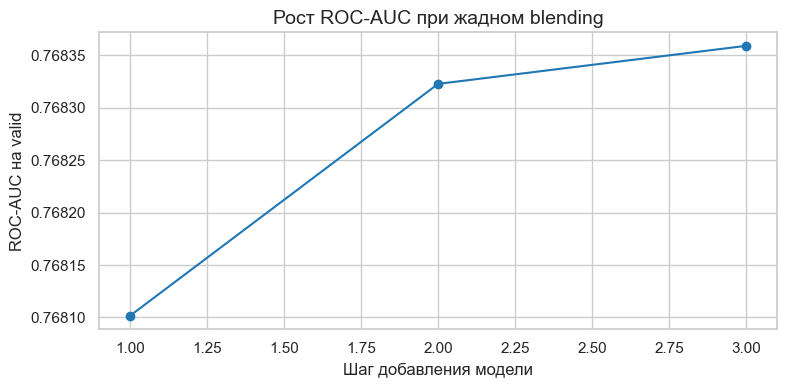

In [10]:
def greedy_blend(y_true, predictions, max_models=8):
    scores = {col: roc_auc_score(y_true, predictions[col]) for col in predictions.columns}
    selected = [max(scores, key=scores.get)]
    current_pred = predictions[selected[0]].values.copy()
    current_score = roc_auc_score(y_true, current_pred)
    history = [{"step": 1, "added_model": selected[0], "weight_old": 0.0, "roc_auc": current_score}]
    remaining = [c for c in predictions.columns if c not in selected]

    while remaining and len(selected) < max_models:
        best_candidate = None
        best_pred = None
        best_score = current_score
        best_weight = None

        for candidate in remaining:
            for weight_old in np.linspace(0.1, 0.9, 17):
                blended = weight_old * current_pred + (1 - weight_old) * predictions[candidate].values
                score = roc_auc_score(y_true, blended)
                if score > best_score:
                    best_score = score
                    best_candidate = candidate
                    best_pred = blended
                    best_weight = weight_old

        if best_candidate is None:
            break

        selected.append(best_candidate)
        remaining.remove(best_candidate)
        current_pred = best_pred
        current_score = best_score
        history.append({
            "step": len(selected),
            "added_model": best_candidate,
            "weight_old": best_weight,
            "roc_auc": current_score,
        })

    return current_pred, selected, pd.DataFrame(history)


SUBMIT_CUTOFF = "2025-02-01"
MODEL_NAMES = ["xgb_base", "cat_base", "lgbm_base"]

data = train_df.copy()
X_all, y_all, _ = build_feature_set(data, feature_set="ratio_reduced")
X_all = apply_reduced_v2_no_ratios(X_all)

train_mask = data[DATE_COL] < pd.Timestamp(SUBMIT_CUTOFF)
valid_mask = ~train_mask
X_train, X_valid = X_all.loc[train_mask], X_all.loc[valid_mask]
y_train, y_valid = y_all.loc[train_mask].astype(int), y_all.loc[valid_mask].astype(int)

print(f"Train: {len(X_train)} | Valid: {len(X_valid)} | Features: {X_train.shape[1]}")

valid_predictions = pd.DataFrame(index=X_valid.index)
model_results = []

for model_name in MODEL_NAMES:
    model_id = f"{model_name}__reduced_v2_no_ratios"
    print(f"Обучение {model_id}...")
    _, valid_pred = fit_predict_model(model_name, X_train, y_train, X_valid, y_valid)
    metrics = evaluate_predictions(y_valid, valid_pred)
    valid_predictions[model_id] = valid_pred
    model_results.append({"model_id": model_id, **metrics})
    print(f"  ROC-AUC={metrics['roc_auc']:.6f} | PR-AUC={metrics['pr_auc']:.6f}")

greedy_pred, selected_models, blend_history = greedy_blend(y_valid, valid_predictions)
blend_metrics = evaluate_predictions(y_valid, greedy_pred)

print("\nGreedy blend:")
print(f"  ROC-AUC={blend_metrics['roc_auc']:.6f} | PR-AUC={blend_metrics['pr_auc']:.6f}")
print("  Модели:", selected_models)
display(blend_history)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(blend_history["step"], blend_history["roc_auc"], marker="o", color="#1f77b4")
ax.set_title("Рост ROC-AUC при жадном blending")
ax.set_xlabel("Шаг добавления модели")
ax.set_ylabel("ROC-AUC на valid")
plt.tight_layout()
plt.show()


### **Финальное обучение и submission**

Веса ансамбля $w^*$ подобраны на validation. Для финального предсказания на test **каждая модель переобучается на полном train** (train + valid), чтобы использовать максимально возможный объём данных:

$$
\hat{p}^{\text{test}} = \text{blend}(f_\text{xgb}(X_\text{test}),\; f_\text{cat}(X_\text{test}),\; f_\text{lgbm}(X_\text{test}); \; w^*),
$$

где $f_m$ - модель $m$, обученная на всём `train_df`. Веса $w^*$ при этом не пересчитываются - перебор весов на полных данных без holdout приведёт к переобучению.

Submission: файл `submission_final.csv` содержит столбцы `front_id` и `target_value` (вероятности), упорядоченные по `front_id` из `test_apps.csv`.


In [11]:
def fit_full_model_predict(model_name, X_train, y_train, X_test):
    X_train_ready, X_test_ready, cat_features = prepare_model_data(X_train, X_test, model_name)
    model = make_model(model_name)
    if model_name.startswith("cat"):
        model.fit(X_train_ready, y_train, cat_features=cat_features)
    elif model_name.startswith("lgbm"):
        model.fit(X_train_ready, y_train, categorical_feature=cat_features)
    else:
        model.fit(X_train_ready, y_train)
    return model.predict_proba(X_test_ready)[:, 1]


X_full, y_full, X_test = build_feature_set(train_df, test_df, feature_set="ratio_reduced")
X_full = apply_reduced_v2_no_ratios(X_full)
X_test = apply_reduced_v2_no_ratios(X_test)
y_full = y_full.astype(int)

test_predictions = {}
for model_id in selected_models:
    model_name = model_id.split("__", 1)[0]
    print(f"Финальное обучение: {model_id}")
    test_predictions[model_id] = fit_full_model_predict(model_name, X_full, y_full, X_test)

test_blend = test_predictions[selected_models[0]].copy()
for step in range(1, len(selected_models)):
    weight_old = blend_history.loc[step, "weight_old"]
    test_blend = weight_old * test_blend + (1 - weight_old) * test_predictions[selected_models[step]]

submission = pd.DataFrame({
    "front_id": test_df[ID_COL],
    "target_value": test_blend,
})
submission.to_csv("submission_final.csv", index=False)

print(f"Сохранено: submission_final.csv | shape={submission.shape}")
display(submission.head())
submission["target_value"].describe()


Финальное обучение: xgb_base__reduced_v2_no_ratios
Финальное обучение: cat_base__reduced_v2_no_ratios
Финальное обучение: lgbm_base__reduced_v2_no_ratios
Сохранено: submission_final.csv | shape=(36311, 2)


,front_id,target_value
0,150378,0.061814
1,194170,0.040862
2,102106,0.008022
3,256199,0.024039
4,253573,0.035467


count    36311.000000
mean         0.092329
std          0.127654
min          0.001523
25%          0.025123
50%          0.049634
75%          0.099090
max          0.915690
Name: target_value, dtype: float64